In [1]:
# ================================================================
#  Imports
# ================================================================
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import subprocess
from pathlib import Path
from io import StringIO
import re
import time
import xarray as xr
# ================================================================
#  Working directory and HS2SWE import
# ================================================================
os.chdir('/Users/jakobwerkgarner/code/mt_dsnow')



import HS2SWE.model.HS2SWE as hs2swe





# Load the data

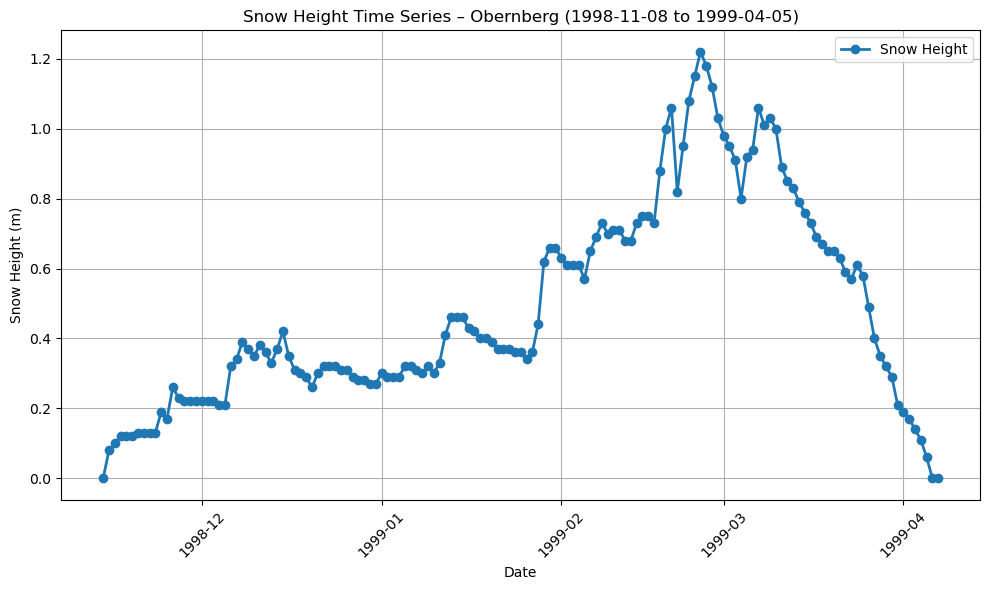

In [2]:
# ================================================================
#  Load Obernberg data and subset period
# ================================================================
data = pd.read_csv(
    "calibration/calibration_data/output/HS_SWE_by_station/Obernberg_hs_swe_obs.csv"
)
data["date"] = pd.to_datetime(data["date"])

# full season subset
data_season = data[(data["date"] >= "1998-11-14") & (data["date"] <= "1999-04-07")].copy()

dates_all = data_season["date"].to_numpy()
n_days = len(data_season)


hs_obs = data_season["hs"]

# Quick HS plot
plt.figure(figsize=(10, 6))
plt.plot(data_season["date"], data_season["hs"], marker="o", linewidth=2, label="Snow Height")
plt.xlabel("Date")
plt.ylabel("Snow Height (m)")
plt.title("Snow Height Time Series – Obernberg (1998-11-08 to 1999-04-05)")
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [3]:
# Prepare correct shape of data array for model input
idata = np.array(data_season['hs']).reshape(-1,1)

np.shape(idata.reshape(-1,1))



(145, 1)

# Model Runs


run in R reults save as nc file and loaded here

In [4]:
# ``layer_model_run`` folder and saved as NetCDF
ds_delta_snow = xr.open_dataset("/Users/jakobwerkgarner/code/mt_dsnow/model_diff/dsnow/layer_model_run/delta_snow_result.nc")

In [5]:
#run hs2swe model


# Prepare correct shape of data array for model input
idata = np.array(data_season['hs']).reshape(-1,1) * 100 # cm for HS2SWE

np.shape(idata.reshape(-1,1))

ds_hs2swe = hs2swe.HS2SWE(idata)

Running station: 1
Elapsed time for Station, 1 : 0.10618901252746582 s
Average time per station: 0.10634303092956543 s


In [6]:
# Merge HS2SWE and Delta.snow SWE into a pandas DataFrame with time index from ds_delta_snow

df_merged = pd.DataFrame({
    "date": pd.to_datetime(ds_delta_snow.dates.values.astype(str)),
    "SWE_dsnow": ds_delta_snow.SWE.values,
    "SWE_hs2swe": ds_hs2swe.flatten()
})

# Compare first results

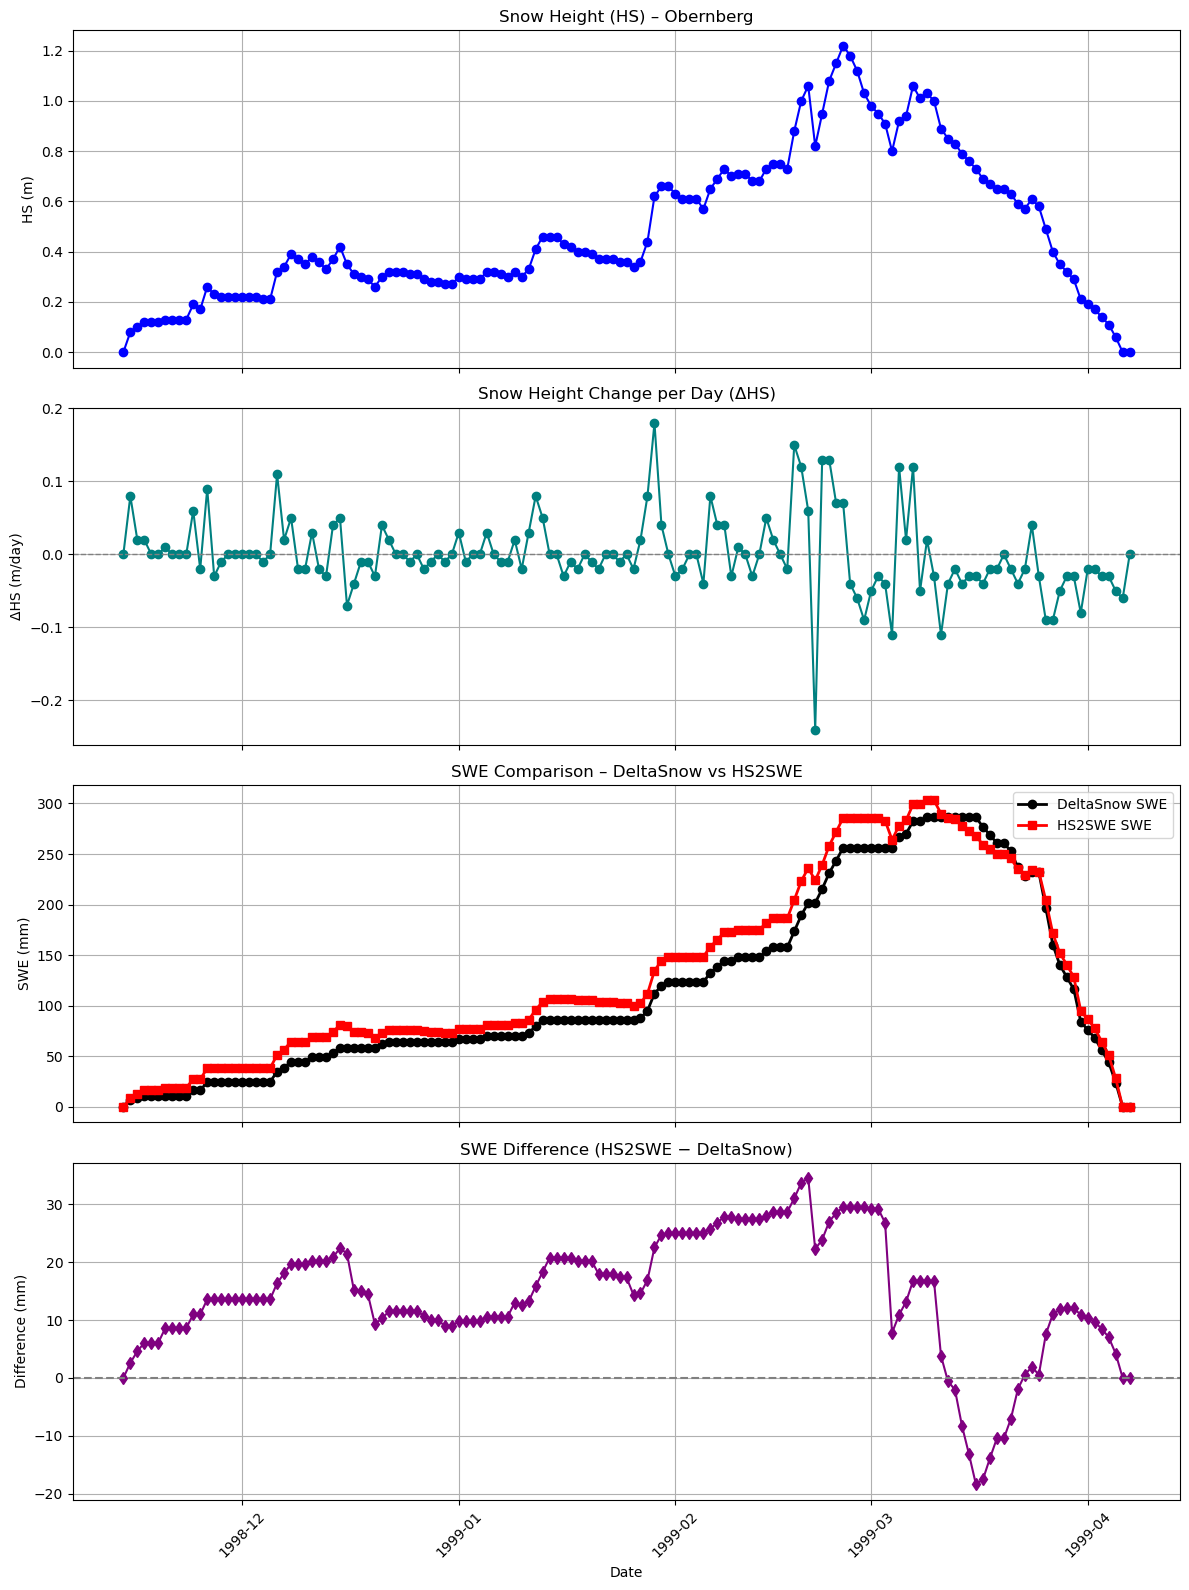

In [7]:
# ================================================================
#  Multi-panel Comparison Plot (HS + ΔHS + SWE + Difference)
# ================================================================
fig, axs = plt.subplots(4, 1, figsize=(12, 16), sharex=True)

dates = df_merged["date"]

# 1) Snow height
axs[0].plot(data_season["date"], data_season["hs"], marker="o", color="blue")
axs[0].set_ylabel("HS (m)")
axs[0].set_title("Snow Height (HS) – Obernberg")
axs[0].grid(True)

# 2) Snow height difference
HS_diff = np.diff(data_season["hs"], prepend=data_season["hs"].iloc[0])
axs[1].plot(data_season["date"], HS_diff, marker="o", color="teal")
axs[1].axhline(0, color="gray", linestyle="--", linewidth=1)
axs[1].set_ylabel("ΔHS (m/day)")
axs[1].set_title("Snow Height Change per Day (ΔHS)")
axs[1].grid(True)

# 3) SWE Comparison
axs[2].plot(df_merged["date"], df_merged["SWE_dsnow"],
            marker="o", linestyle="-", linewidth=2, color="black", label="DeltaSnow SWE")
axs[2].plot(df_merged["date"], df_merged["SWE_hs2swe"],
            marker="s", linestyle="-", linewidth=2, color="red", label="HS2SWE SWE")
axs[2].set_ylabel("SWE (mm)")
axs[2].set_title("SWE Comparison – DeltaSnow vs HS2SWE")
axs[2].grid(True)
axs[2].legend()

# 4) SWE Difference
swe_diff = df_merged["SWE_hs2swe"] - df_merged["SWE_dsnow"]
axs[3].plot(df_merged["date"], swe_diff, marker="d", color="purple")
axs[3].axhline(0, color="gray", linestyle="--")
axs[3].set_ylabel("Difference (mm)")
axs[3].set_title("SWE Difference (HS2SWE − DeltaSnow)")
axs[3].grid(True)

plt.xlabel("Date")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Detailes Look

## Model Runs

In [14]:
# ================================================================
#  HS2SWE DEBUG-STYLE RUN (layer-resolved) FOR ONE STATION
#  → builds MR + DEBUG and then full-season layer fields
# ================================================================
# Model parameters
RhoNew    = 113.7
RhoMax    = 571.6
SnoTemp   = -0.000
Visc      = 6.051e7
DQMultInc = 0.1
DQMultMax = 5
HsAcc     = 2

c1, c2, c3, c4, c5 = 2.8e-6, 0.042, 0.046, 0.081, 0.018
g, dt = 9.81, 86400

PAR = {"c1": c1, "c2": c2, "c3": c3, "c4": c4, "c5": c5, "g": g, "dt": dt}



# Input array for custom HS2SWE run
idata = idata * 100  # shape (n_days, 1)
assert np.all(idata[~np.isnan(idata)] >= 0), "Negative values in input data"

odata = np.zeros_like(idata)


# ================================================================
#  DEBUG STORAGE STRUCTURE
# ================================================================
DEBUG = {
    "stations": [],
    "HS_series": [],
    "RHO_series": [],
    "OVB_series": [],
    "AGE_series": [],
    "DIA_series": [],
    "SWE_series": [],
    "TERM_OVB_series": [],
    "TERM_SETTLE_series": [],
    "DENS_TOTAL_series": [],
    "TERM_DRHO_series": [],
    "SETTLE_FACTOR_series": [],
    "DELTA_HS_SETTLE_series": [],
    "period_info": [],
}

start_all = time.time()

odata = np.zeros_like(idata)


# ================================================================
#  LOOP OVER STATIONS
# ================================================================
for serix in range(idata.shape[1]):

    HS_input = idata[:, serix]
    psdix = np.where((~np.isnan(HS_input)) & (HS_input > 0))[0]

    if psdix.size == 0:
        continue

    # split continuous snow periods
    sepix = np.concatenate(([0], np.where(np.diff(psdix) > 1)[0] + 1, [len(psdix)]))

    # per-station collectors
    station_HS = []
    station_RHO = []
    station_OVB = []
    station_AGE = []
    station_DIA = []
    station_SWE = []

    station_TERM_OVB = []
    station_TERM_SETTLE = []
    station_DENS_TOTAL = []
    station_TERM_DRHO = []
    station_SETTLE_FACTOR = []
    station_DELTA_HS_SETTLE = []


    # ============================================================
    #  LOOP OVER SNOW PERIODS
    # ============================================================
    for p in range(len(sepix) - 1):

        idx1 = psdix[sepix[p]]
        idx2 = psdix[sepix[p + 1] - 1]

        HS = np.concatenate([[0], HS_input[idx1:idx2 + 1]])

        # ========================================================
        #  INITIALIZE MR STRUCTURES (physics identical to original)
        # ========================================================
        MR = {
            "HS":  np.zeros((1, len(HS))),
            "RHO": np.ones((1, len(HS))) * RhoMax,    # EXACT original initialization
            "OVB": np.zeros((1, len(HS))),
            "AGE": np.arange(len(HS))[None, :],
            "DIA": np.zeros((5, len(HS))),

            # diagnostics (same shape as HS/RHO)
            "TERM_OVB":         np.zeros((1, len(HS))),
            "TERM_SETTLE":      np.zeros((1, len(HS))),
            "DENS_TOTAL":       np.zeros((1, len(HS))),
            "TERM_DRHO":        np.zeros((1, len(HS))),
            "SETTLE_FACTOR":    np.zeros((1, len(HS))),
            "DELTA_HS_SETTLE":  np.zeros((1, len(HS))),
        }


        # ========================================================
        #  LOOP OVER TIMESTEPS
        # ========================================================
        for tn in range(1, len(HS)):

            # ------------------------------------------------------------------
            # Step 1: densification  (EXACT PHYSICS + diagnostics)
            # ------------------------------------------------------------------
            rho_prev = MR["RHO"][:, tn - 1]

            term_overburden = (
                MR["OVB"][:, tn - 1] * PAR["g"] /
                (Visc * np.exp(PAR["c4"] * SnoTemp + PAR["c5"] * rho_prev))
            )

            term_settling = (
                PAR["c1"] *
                np.exp(
                    -PAR["c2"] * SnoTemp
                    - PAR["c3"] * np.maximum(0, rho_prev - RhoNew)
                )
            )

            term_total = term_overburden + term_settling
            delta_rho  = rho_prev * PAR["dt"] * term_total

            MR["RHO"][:, tn] = np.minimum(rho_prev + delta_rho, RhoMax)

            # store diagnostics
            MR["TERM_OVB"][:, tn]    = term_overburden
            MR["TERM_SETTLE"][:, tn] = term_settling
            MR["DENS_TOTAL"][:, tn]  = term_total
            MR["TERM_DRHO"][:, tn]   = delta_rho


            # ------------------------------------------------------------------
            # Step 2: settling  (EXACT PHYSICS + diagnostics)
            # ------------------------------------------------------------------
            rho_new = MR["RHO"][:, tn]
            HS_prev = MR["HS"][:, tn - 1]

            settle_factor = rho_prev / rho_new
            HS_new        = HS_prev * settle_factor
            delta_HS      = HS_new - HS_prev

            MR["HS"][:, tn] = HS_new

            MR["SETTLE_FACTOR"][:, tn]   = settle_factor
            MR["DELTA_HS_SETTLE"][:, tn] = delta_HS


            # ------------------------------------------------------------------
            # Step 3: ASSIMILATION  (COPY OF ORIGINAL LOGIC)
            # ------------------------------------------------------------------
            HSmod = np.sum(MR["HS"][:, tn])
            HSobs = HS[tn]

            # === Step 3.0 ===
            if HSobs > HSmod and tn == 1:
                nl = MR["HS"].shape[0] + 1
                for key in ["HS", "RHO", "OVB", "AGE",
                            "TERM_OVB", "TERM_SETTLE", "DENS_TOTAL",
                            "TERM_DRHO", "SETTLE_FACTOR", "DELTA_HS_SETTLE"]:
                    MR[key] = np.vstack([MR[key], np.zeros((1, len(HS)))])

                MR["HS"][nl - 1, tn]  = HSobs - HSmod
                MR["RHO"][nl - 1, :]  = RhoNew
                MR["AGE"][nl - 1, tn:] = np.arange(len(HS) - tn)

            # === Step 3.1 ===
            elif HSobs > HSmod + HsAcc:
                nl = MR["HS"].shape[0] + 1
                for key in ["HS", "RHO", "OVB", "AGE",
                            "TERM_OVB", "TERM_SETTLE", "DENS_TOTAL",
                            "TERM_DRHO", "SETTLE_FACTOR", "DELTA_HS_SETTLE"]:
                    MR[key] = np.vstack([MR[key], np.zeros((1, len(HS)))])

                MR["HS"][nl - 1, tn] = HSobs - HSmod
                MR["RHO"][nl - 1, :] = RhoNew

            # === Step 3.2 ===
            elif np.isclose(HSobs, HSmod):
                pass

            # === Step 3.3 (underestimate) ===
            elif HSobs > HSmod:
                DQMultCur = 1
                while (np.mean(MR["RHO"][:, tn]) < RhoMax and
                       HSobs > np.sum(MR["HS"][:, tn]) and
                       DQMultCur < DQMultMax):

                    DQMultCur += DQMultInc

                    MR["RHO"][:, tn] = np.minimum(
                        rho_prev + delta_rho / DQMultCur,
                        RhoMax
                    )
                    MR["HS"][:, tn] = HS_prev * (rho_prev / MR["RHO"][:, tn])

            # === Step 3.4 (overestimate) ===
            elif HSobs < HSmod:
                excess = HSmod - HSobs
                for lix in range(MR["HS"].shape[0] - 1, -1, -1):
                    take = min(excess, MR["HS"][lix, tn])
                    MR["HS"][lix, tn] -= take
                    excess -= take
                    if excess <= 0:
                        break


            # ------------------------------------------------------------------
            # Step 4: recalc OVB (identical to original)
            # ------------------------------------------------------------------
            MR["OVB"][-1, tn] = 0
            for lix in range(MR["HS"].shape[0] - 2, -1, -1):
                MR["OVB"][lix, tn] = np.sum(
                    MR["HS"][lix + 1 :, tn] * MR["RHO"][lix + 1 :, tn] / 100
                )


        # ========================================================
        #  END OF PERIOD — compute SWE
        # ========================================================
        SWE = np.sum(MR["HS"] * MR["RHO"] / 100.0, axis=0)
        odata[idx1:idx2 + 1, serix] = SWE[1:]

        # store all arrays
        station_HS.append(MR["HS"])
        station_RHO.append(MR["RHO"])
        station_OVB.append(MR["OVB"])
        station_AGE.append(MR["AGE"])
        station_DIA.append(MR["DIA"])
        station_SWE.append(SWE)

        station_TERM_OVB.append(MR["TERM_OVB"])
        station_TERM_SETTLE.append(MR["TERM_SETTLE"])
        station_DENS_TOTAL.append(MR["DENS_TOTAL"])
        station_TERM_DRHO.append(MR["TERM_DRHO"])
        station_SETTLE_FACTOR.append(MR["SETTLE_FACTOR"])
        station_DELTA_HS_SETTLE.append(MR["DELTA_HS_SETTLE"])

        DEBUG["period_info"].append({
            "station": serix,
            "period_index": p,
            "start": idx1,
            "end": idx2,
            "HS": HS,
            "SWE": SWE,
            "layers": MR["HS"].shape[0]
        })


    # ============================================================
    #  Save station results
    # ============================================================
    DEBUG["stations"].append(serix)
    DEBUG["HS_series"].append(station_HS)
    DEBUG["RHO_series"].append(station_RHO)
    DEBUG["OVB_series"].append(station_OVB)
    DEBUG["AGE_series"].append(station_AGE)
    DEBUG["DIA_series"].append(station_DIA)
    DEBUG["SWE_series"].append(station_SWE)

    DEBUG["TERM_OVB_series"].append(station_TERM_OVB)
    DEBUG["TERM_SETTLE_series"].append(station_TERM_SETTLE)
    DEBUG["DENS_TOTAL_series"].append(station_DENS_TOTAL)
    DEBUG["TERM_DRHO_series"].append(station_TERM_DRHO)
    DEBUG["SETTLE_FACTOR_series"].append(station_SETTLE_FACTOR)
    DEBUG["DELTA_HS_SETTLE_series"].append(station_DELTA_HS_SETTLE)

print("\n=== ALL STATIONS COMPLETE ===")
print(f"Total runtime: {time.time() - start_all:.2f} s")


=== ALL STATIONS COMPLETE ===
Total runtime: 0.08 s


In [20]:
DEBUG.keys()

dict_keys(['stations', 'HS_series', 'RHO_series', 'OVB_series', 'AGE_series', 'DIA_series', 'SWE_series', 'TERM_OVB_series', 'TERM_SETTLE_series', 'DENS_TOTAL_series', 'TERM_DRHO_series', 'SETTLE_FACTOR_series', 'DELTA_HS_SETTLE_series', 'period_info'])

In [22]:
# Export all series from DEBUG to an xarray Dataset with 'layer' and 'time' as coordinates
import xarray as xr
import numpy as np
from pathlib import Path

# Assume DEBUG is a dict with the required keys
# Example keys: 'stations', 'HS_series', 'RHO_series', ...

# Extract arrays and dimensions
stations = DEBUG['stations']  # list of station names
period_info = DEBUG['period_info']  # dict with 'n_time', 'n_layer', 'dates', etc.
n_time = period_info['n_time']
n_layer = period_info['n_layer']
dates = np.array(period_info['dates'])

coords = {
    'station': stations,
    'layer': np.arange(n_layer),
    'time': dates
}

# Prepare data variables (assume all *_series are shaped [station, layer, time])
data_vars = {}
for key in DEBUG:
    if key.endswith('_series'):
        arr = np.array(DEBUG[key])
        # If shape is (station, layer, time), add as is
        if arr.shape == (len(stations), n_layer, n_time):
            data_vars[key.replace('_series', '')] = (('station', 'layer', 'time'), arr)
        # If shape is (station, time), add with layer=0
        elif arr.shape == (len(stations), n_time):
            arr = arr[:, np.newaxis, :]
            data_vars[key.replace('_series', '')] = (('station', 'layer', 'time'), arr)
        # If shape is (layer, time), add with station=0
        elif arr.shape == (n_layer, n_time):
            arr = arr[np.newaxis, :, :]
            data_vars[key.replace('_series', '')] = (('station', 'layer', 'time'), arr)
        # If shape is (time,), add with station=0, layer=0
        elif arr.shape == (n_time,):
            arr = arr[np.newaxis, np.newaxis, :]
            data_vars[key.replace('_series', '')] = (('station', 'layer', 'time'), arr)
        else:
            print(f"Skipping {key}: unexpected shape {arr.shape}")

# Create the Dataset
xr_ds = xr.Dataset(data_vars, coords=coords)

# Save to NetCDF
output_nc = Path('debug_export.nc')
xr_ds.to_netcdf(output_nc)
print(f"Saved NetCDF → {output_nc}")
print(xr_ds)

TypeError: list indices must be integers or slices, not str

### Assimilate data structure

In [ ]:
# Align ds_delta_snow time index and dimension order to match ds_hs2swe
ds_delta_snow = ds_delta_snow.assign_coords(time=pd.to_datetime(ds_hs2swe.time.values))
ds_delta_snow = ds_delta_snow.transpose("layer", "time")
ds_hs2swe = ds_hs2swe.transpose("layer", "time")
print("ds_delta_snow and ds_hs2swe aligned on time and dimension order.")


ds_delta_snow and ds_hs2swe aligned on time and dimension order.


## Basic Comparrison n_layer..

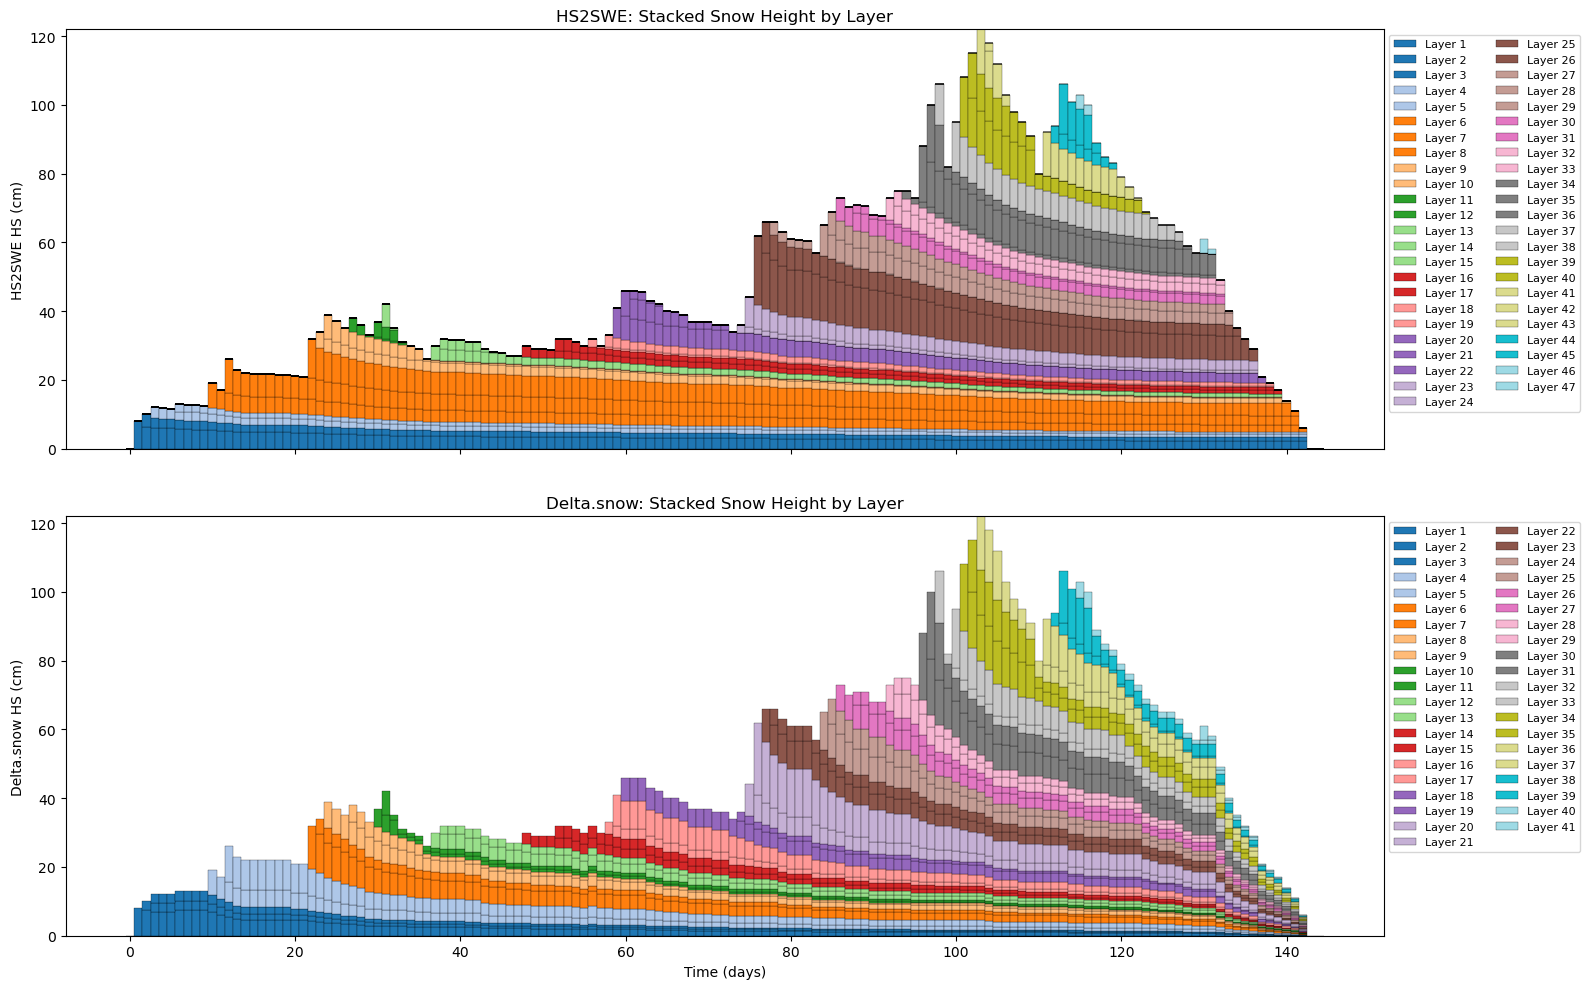

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# HS2SWE layers
bottom = np.zeros(ds_hs2swe.sizes["time"])
for lyr in range(ds_hs2swe.sizes["layer"]):
    axs[0].bar(
        np.arange(ds_hs2swe.sizes["time"]),
        ds_hs2swe["HS"].isel(layer=lyr).values,
        bottom=bottom,
        color=plt.cm.tab20(lyr / ds_hs2swe.sizes["layer"]),
        width=1.0,
        edgecolor='k',
        linewidth=0.2,
        label=f"Layer {lyr+1}" 
    )
    bottom += ds_hs2swe["HS"].isel(layer=lyr).values
axs[0].set_ylabel("HS2SWE HS (cm)")
axs[0].set_title("HS2SWE: Stacked Snow Height by Layer")
axs[0].legend(ncol=2, fontsize=8, loc='upper left', bbox_to_anchor=(1, 1))

# Delta.snow layers from ds_delta_snow
bottom = np.zeros(ds_delta_snow.sizes["time"])
for lyr in range(ds_delta_snow.sizes["layer"]):
    axs[1].bar(
        np.arange(ds_delta_snow.sizes["time"]),
        ds_delta_snow["h"].isel(layer=lyr).values * 100,  # convert m to cm if needed
        bottom=bottom,
        color=plt.cm.tab20(lyr / ds_delta_snow.sizes["layer"]),
        width=1.0,
        edgecolor='k',
        linewidth=0.2,
        label=f"Layer {lyr+1}" 
    )
    bottom += np.nan_to_num(ds_delta_snow["h"].isel(layer=lyr).values * 100)
axs[1].set_ylabel("Delta.snow HS (cm)")
axs[1].set_title("Delta.snow: Stacked Snow Height by Layer")
axs[1].legend(ncol=2, fontsize=8, loc='upper left', bbox_to_anchor=(1, 1))

axs[1].set_xlabel("Time (days)")
plt.tight_layout()
plt.show()


##  Density Comparisson 

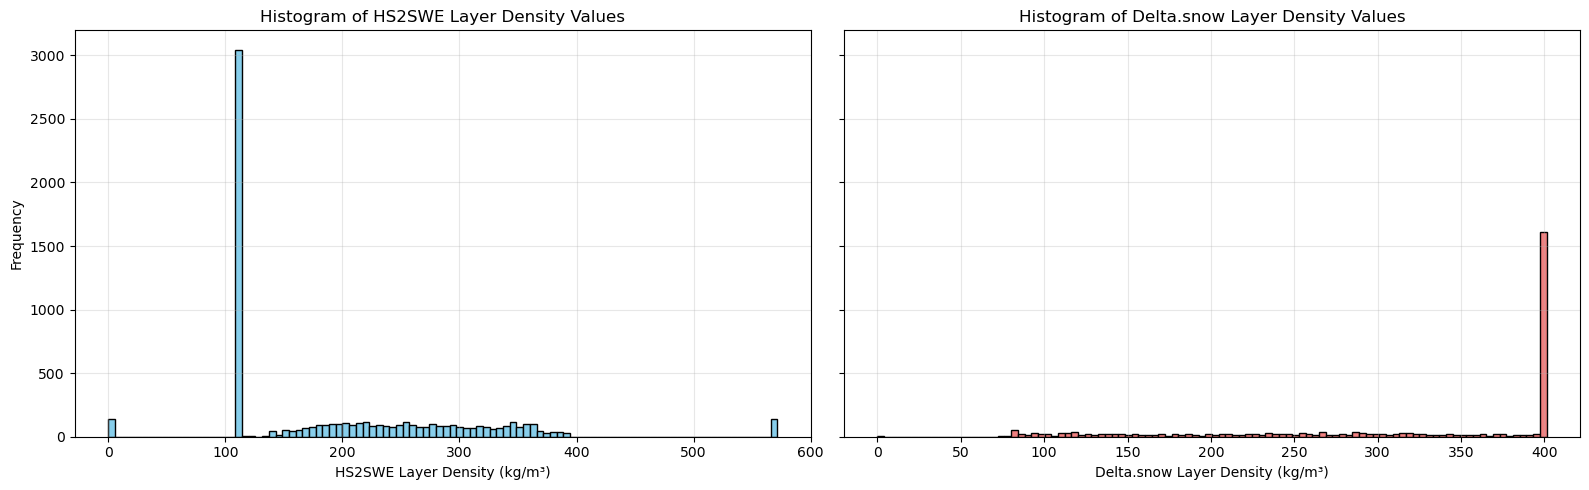

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

# HS2SWE histogram
axs[0].hist(ds_hs2swe["RHO"].values.flatten(), bins=100, color='skyblue', edgecolor='black')
axs[0].set_xlabel("HS2SWE Layer Density (kg/m³)")
axs[0].set_ylabel("Frequency")
axs[0].set_title("Histogram of HS2SWE Layer Density Values")
axs[0].grid(True, alpha=0.3)

# Delta.snow histogram
axs[1].hist(ds_delta_snow["rho"].values.flatten(), bins=100, color='lightcoral', edgecolor='black')
axs[1].set_xlabel("Delta.snow Layer Density (kg/m³)")
axs[1].set_title("Histogram of Delta.snow Layer Density Values")
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

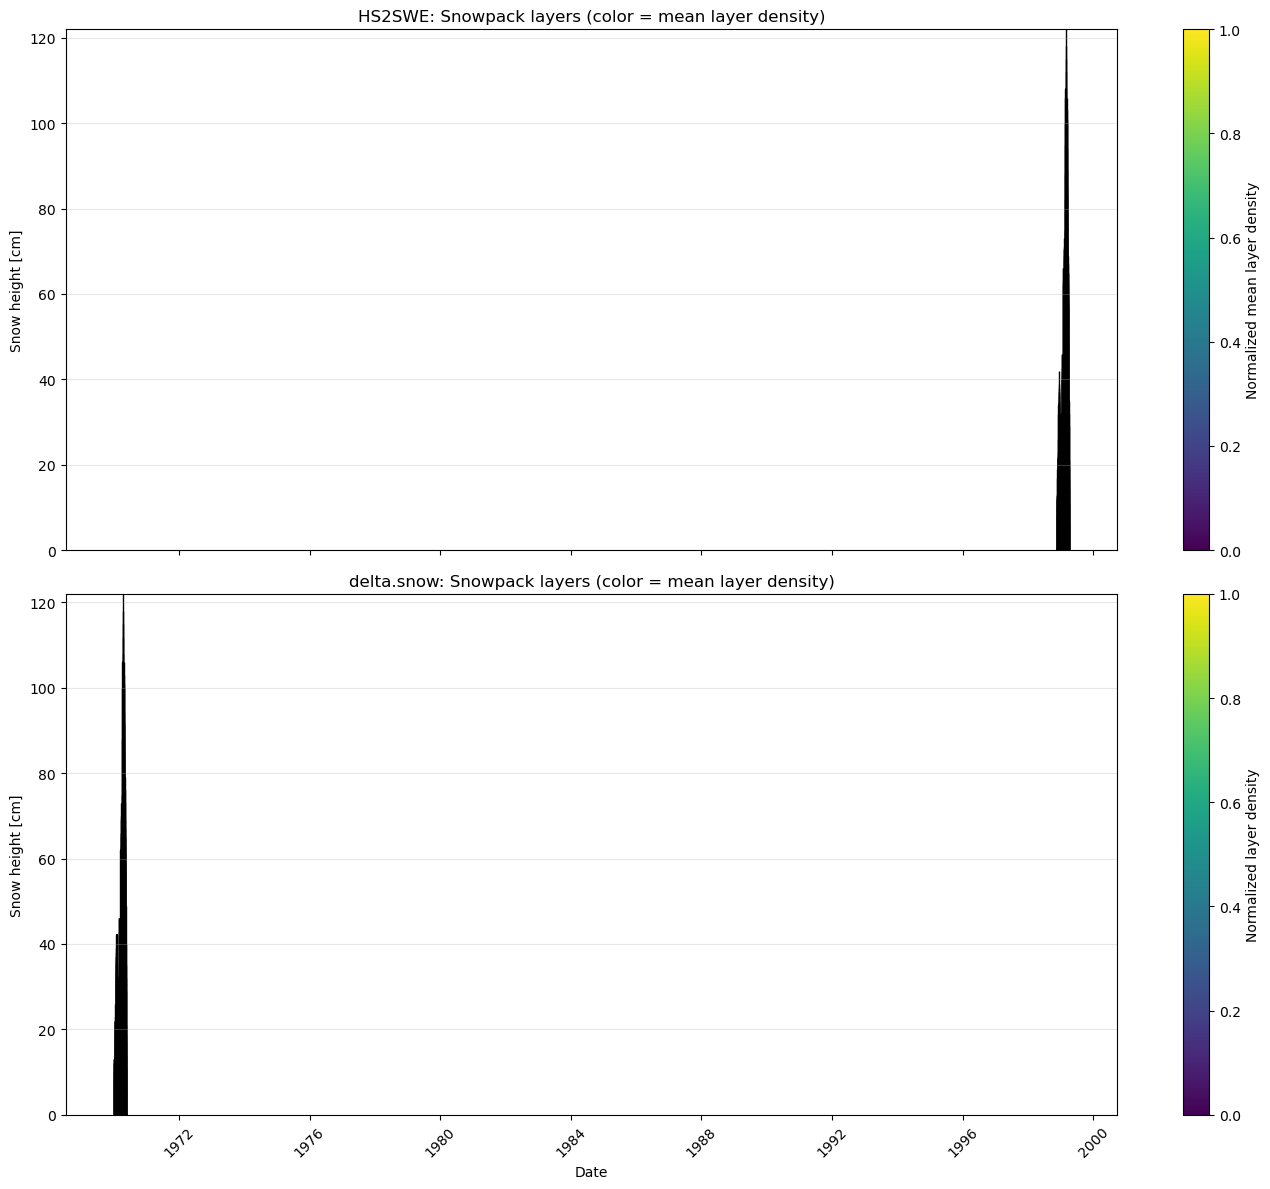

In [ ]:
#roh_max_hs2swe = np.nanmin(ds_hs2swe["RHO"].values)
roh_max_hs2swe = np.nanmax(ds_delta_snow["rho"].values)
rho_max_dsnow = np.nanmax(ds_delta_snow["rho"].values)


#Normalize the values to have coomparable values in the plot
dsnow_rho_norm_layer = ds_delta_snow["rho"].values / rho_max_dsnow
hs2swe_rho_norm_layer = ds_hs2swe["RHO"].values / roh_max_hs2swe

from matplotlib.colors import Normalize

cmap = plt.cm.viridis
norm = Normalize(vmin=0, vmax=1)

fig, axs = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

# ============================================================
# HS2SWE
# ============================================================

bottom = np.zeros(hs2swe_hs.shape[1])

for lyr in range(hs2swe_hs.shape[0]):
    axs[0].bar(
        ds_hs2swe.time.values,
        hs2swe_hs[lyr],
        bottom=bottom,
        color=cmap(norm(hs2swe_rho_norm_layer[lyr])),
        width=1.0,
        edgecolor="k"
    )
    bottom += hs2swe_hs[lyr]

sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
plt.colorbar(sm, ax=axs[0], label="Normalized mean layer density")

axs[0].set_title("HS2SWE: Snowpack layers (color = mean layer density)")
axs[0].set_ylabel("Snow height [cm]")
axs[0].grid(axis="y", alpha=0.3)

# ============================================================
# DELTA.SNOW
# ============================================================

bottom = np.zeros(dsnow_hs.shape[1])

for lyr in range(dsnow_hs.shape[0]):
    hs_layer = np.nan_to_num(dsnow_hs[lyr])
    axs[1].bar(
        ds_delta_snow.time.values,
        hs_layer,
        bottom=bottom,
        color=cmap(norm(dsnow_rho_norm_layer[lyr])),
        width=1.0,
        edgecolor="k"
    )
    bottom += hs_layer

plt.colorbar(sm, ax=axs[1], label="Normalized layer density")

axs[1].set_title("delta.snow: Snowpack layers (color = mean layer density)")
axs[1].set_ylabel("Snow height [cm]")
axs[1].set_xlabel("Date")
axs[1].grid(axis="y", alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# ================================================================
#  Build full-season layer fields (HS, RHO, OVB, AGE) on DATE axis
#  → show ALL periods; zeros where no snow (SWE=0)
# ================================================================
station_index = 0  # only one station anyway

periods = [info for info in DEBUG["period_info"] if info["station"] == station_index]
max_layers = max(info["layers"] for info in periods)

HS_full  = np.zeros((max_layers, n_days))
RHO_full = np.zeros((max_layers, n_days))
OVB_full = np.zeros((max_layers, n_days))
AGE_full = np.zeros((max_layers, n_days))

# fill fields period by period
for p_idx, info in enumerate(periods):
    idx1, idx2 = info["start"], info["end"]
    # local matrices:
    HS_p  = DEBUG["HS_series"][station_index][p_idx]
    RHO_p = DEBUG["RHO_series"][station_index][p_idx]
    OVB_p = DEBUG["OVB_series"][station_index][p_idx]
    AGE_p = DEBUG["AGE_series"][station_index][p_idx]

    # HS_p etc shape: (layers_p, len(HS_period))
    layers_p, lenp = HS_p.shape

    # local time index: j=1..lenp-1 corresponds to global idx1..idx2
    for day_abs in range(idx1, idx2 + 1):
        j = (day_abs - idx1) + 1  # skip j=0 (the leading 0)
        for lyr in range(layers_p):
            HS_full[lyr, day_abs]  = HS_p[lyr, j]
            RHO_full[lyr, day_abs] = RHO_p[lyr, j]
            OVB_full[lyr, day_abs] = OVB_p[lyr, j]
            AGE_full[lyr, day_abs] = AGE_p[lyr, j]

Full-season snowpack + diagnostics reconstructed!


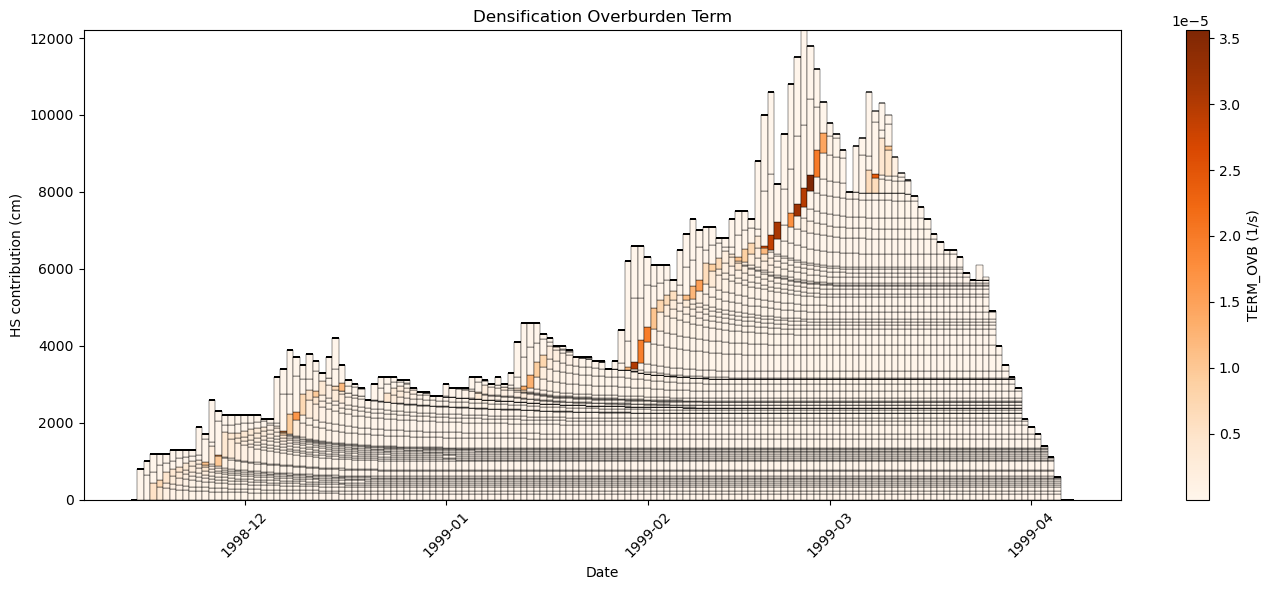

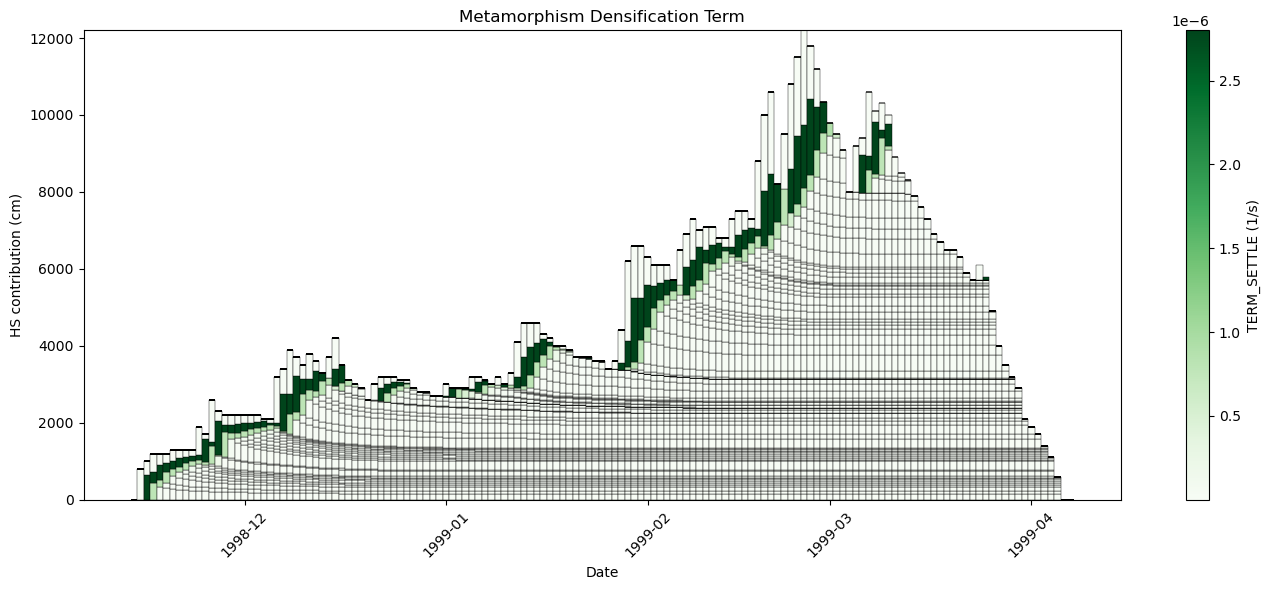

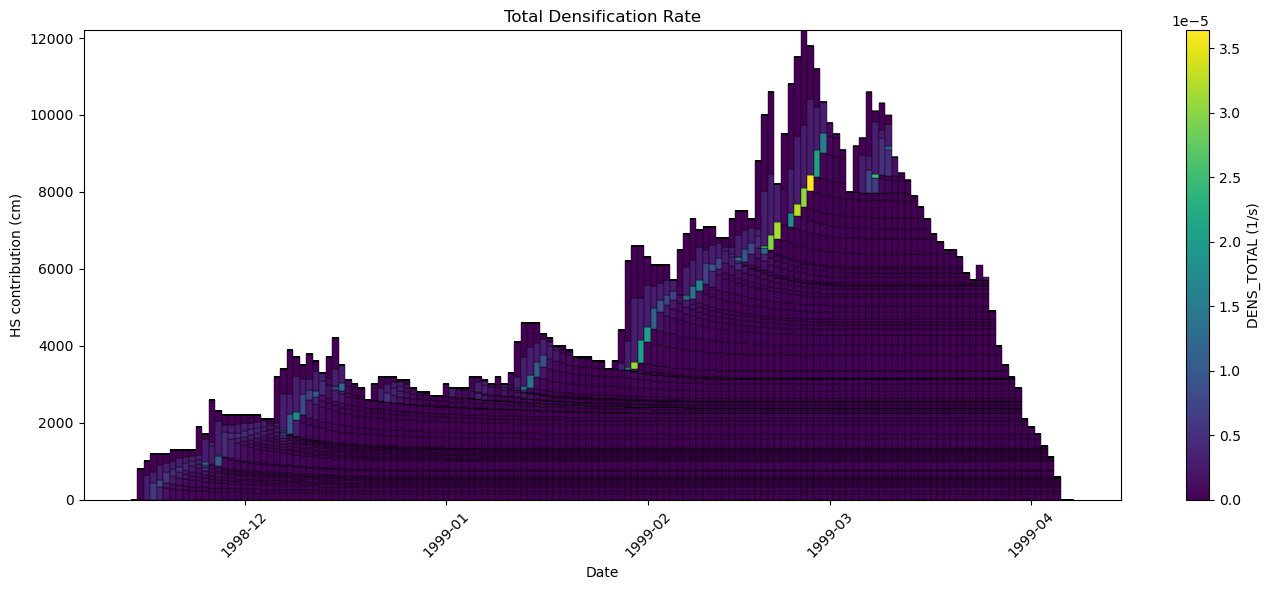

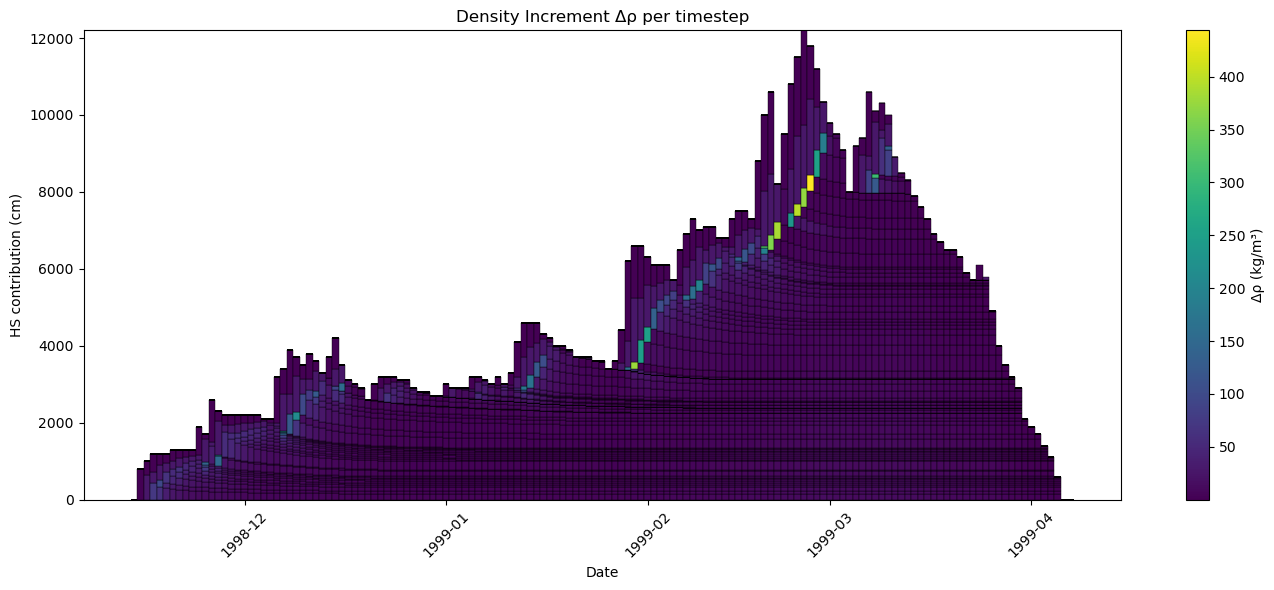

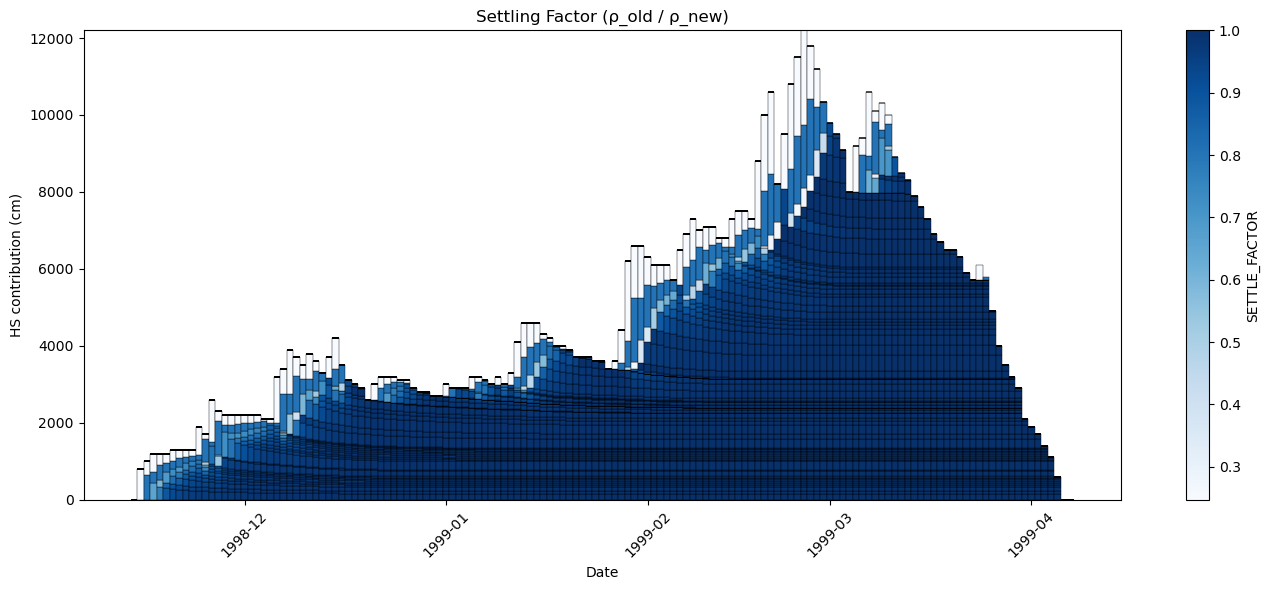

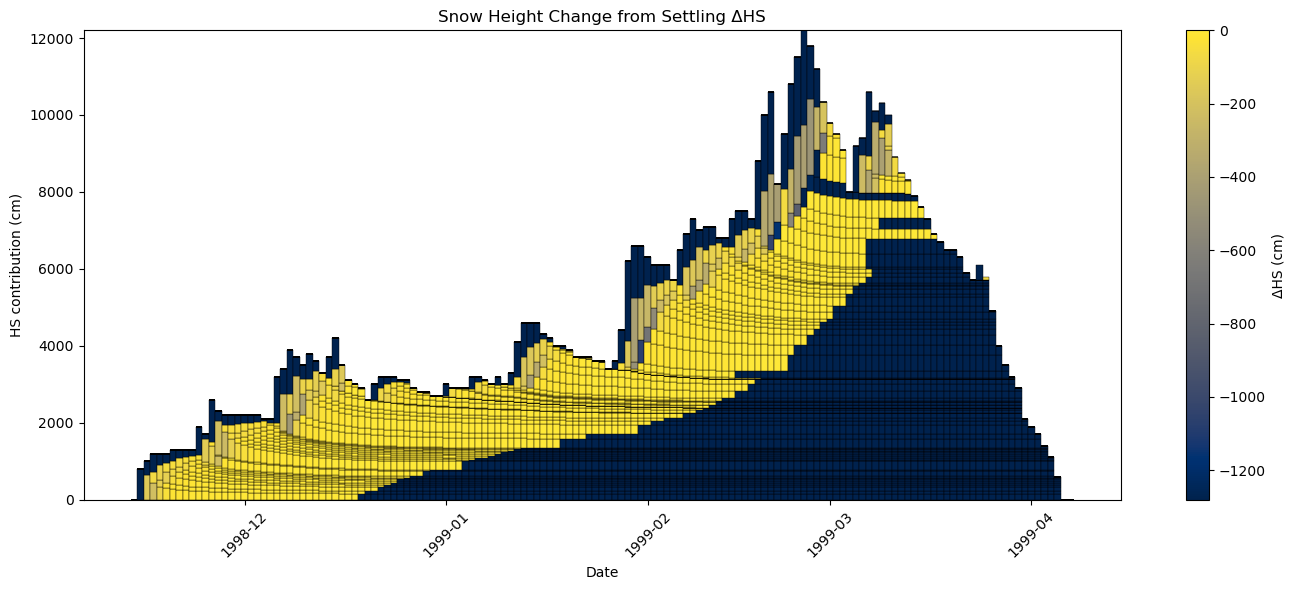

In [ ]:
# ===================================================================
#  REBUILD FULL-SEASON DIAGNOSTIC MATRICES (ALL PERIODS)
# ===================================================================

station_index = 0
n_days = len(idata)
periods = [info for info in DEBUG["period_info"] if info["station"] == station_index]
max_layers = max(info["layers"] for info in periods)

# Allocate full-season fields
HS_full               = np.zeros((max_layers, n_days))
RHO_full              = np.zeros((max_layers, n_days))
OVB_full              = np.zeros((max_layers, n_days))
AGE_full              = np.zeros((max_layers, n_days))

TERM_OVB_full         = np.zeros((max_layers, n_days))
TERM_SETTLE_full      = np.zeros((max_layers, n_days))
DENS_TOTAL_full       = np.zeros((max_layers, n_days))
TERM_DRHO_full        = np.zeros((max_layers, n_days))
SETTLE_FACTOR_full    = np.zeros((max_layers, n_days))
DELTA_HS_SETTLE_full  = np.zeros((max_layers, n_days))


# -------------------------------------------------------------------
# Fill matrices from each snow period
# -------------------------------------------------------------------
for p_idx, info in enumerate(periods):
    idx1, idx2 = info["start"], info["end"]

    HS_p   = DEBUG["HS_series"][station_index][p_idx]
    RHO_p  = DEBUG["RHO_series"][station_index][p_idx]
    OVB_p  = DEBUG["OVB_series"][station_index][p_idx]
    AGE_p  = DEBUG["AGE_series"][station_index][p_idx]

    TERM_OVB_p        = DEBUG["TERM_OVB_series"][station_index][p_idx]
    TERM_SETTLE_p     = DEBUG["TERM_SETTLE_series"][station_index][p_idx]
    DENS_TOTAL_p      = DEBUG["DENS_TOTAL_series"][station_index][p_idx]
    TERM_DRHO_p       = DEBUG["TERM_DRHO_series"][station_index][p_idx]
    SETTLE_FACTOR_p   = DEBUG["SETTLE_FACTOR_series"][station_index][p_idx]
    DELTA_HS_p        = DEBUG["DELTA_HS_SETTLE_series"][station_index][p_idx]

    layers_p, lenp = HS_p.shape

    # j=1 corresponds to absolute day idx1
    for j in range(1, lenp):
        day_abs = idx1 + (j - 1)

        for lyr in range(layers_p):

            # main snowpack fields
            HS_full[lyr, day_abs]  = HS_p[lyr, j]
            RHO_full[lyr, day_abs] = RHO_p[lyr, j]
            OVB_full[lyr, day_abs] = OVB_p[lyr, j]
            AGE_full[lyr, day_abs] = AGE_p[lyr, j]

            # diagnostics
            TERM_OVB_full[lyr, day_abs]        = TERM_OVB_p[lyr, j]
            TERM_SETTLE_full[lyr, day_abs]     = TERM_SETTLE_p[lyr, j]
            DENS_TOTAL_full[lyr, day_abs]      = DENS_TOTAL_p[lyr, j]
            TERM_DRHO_full[lyr, day_abs]       = TERM_DRHO_p[lyr, j]
            SETTLE_FACTOR_full[lyr, day_abs]   = SETTLE_FACTOR_p[lyr, j]
            DELTA_HS_SETTLE_full[lyr, day_abs] = DELTA_HS_p[lyr, j]

print("Full-season snowpack + diagnostics reconstructed!")

# ===================================================================
#  Helper plot function: continuous colormap stacked layer barplot
# ===================================================================
def plot_layer_field(HS_field, var_field, dates, title, label, cmap):
    mask = np.where(var_field != 0, var_field, np.nan)
    vmin = np.nanmin(mask)
    vmax = np.nanmax(mask)
    norm = plt.Normalize(vmin=vmin, vmax=vmax)

    fig, ax = plt.subplots(figsize=(14, 6))
    colors = cmap(norm(np.nan_to_num(mask, nan=vmin)))

    bottom = np.zeros(len(dates))
    L = HS_field.shape[0]

    for lyr in range(L):
        layer_colors = [colors[lyr, t] for t in range(len(dates))]
        ax.bar(
            dates,
            HS_field[lyr],
            bottom=bottom,
            color=layer_colors,
            width=1.0,
            edgecolor="k",
            linewidth=0.3
        )
        bottom += HS_field[lyr]

    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array(mask[np.isfinite(mask)])
    plt.colorbar(sm, ax=ax, label=label)

    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel("HS contribution (cm)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# ===================================================================
#  NOW PLOT ALL DIAGNOSTICS
# ===================================================================
plot_layer_field(HS_full, TERM_OVB_full, dates_all,
                 "Densification Overburden Term", 
                 "TERM_OVB (1/s)", plt.cm.Oranges)

plot_layer_field(HS_full, TERM_SETTLE_full, dates_all,
                 "Metamorphism Densification Term", 
                 "TERM_SETTLE (1/s)", plt.cm.Greens)

plot_layer_field(HS_full, DENS_TOTAL_full, dates_all,
                 "Total Densification Rate", 
                 "DENS_TOTAL (1/s)", plt.cm.viridis)

plot_layer_field(HS_full, TERM_DRHO_full, dates_all,
                 "Density Increment Δρ per timestep", 
                 "Δρ (kg/m³)", plt.cm.viridis)

plot_layer_field(HS_full, SETTLE_FACTOR_full, dates_all,
                 "Settling Factor (ρ_old / ρ_new)", 
                 "SETTLE_FACTOR", plt.cm.Blues)

plot_layer_field(HS_full, DELTA_HS_SETTLE_full, dates_all,
                 "Snow Height Change from Settling ΔHS", 
                 "ΔHS (cm)", plt.cm.cividis)

/var/folders/r5/2d5m4_zn37d74npwnbfcpcdh0000gn/T/ipykernel_10104/3744744840.py:26: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


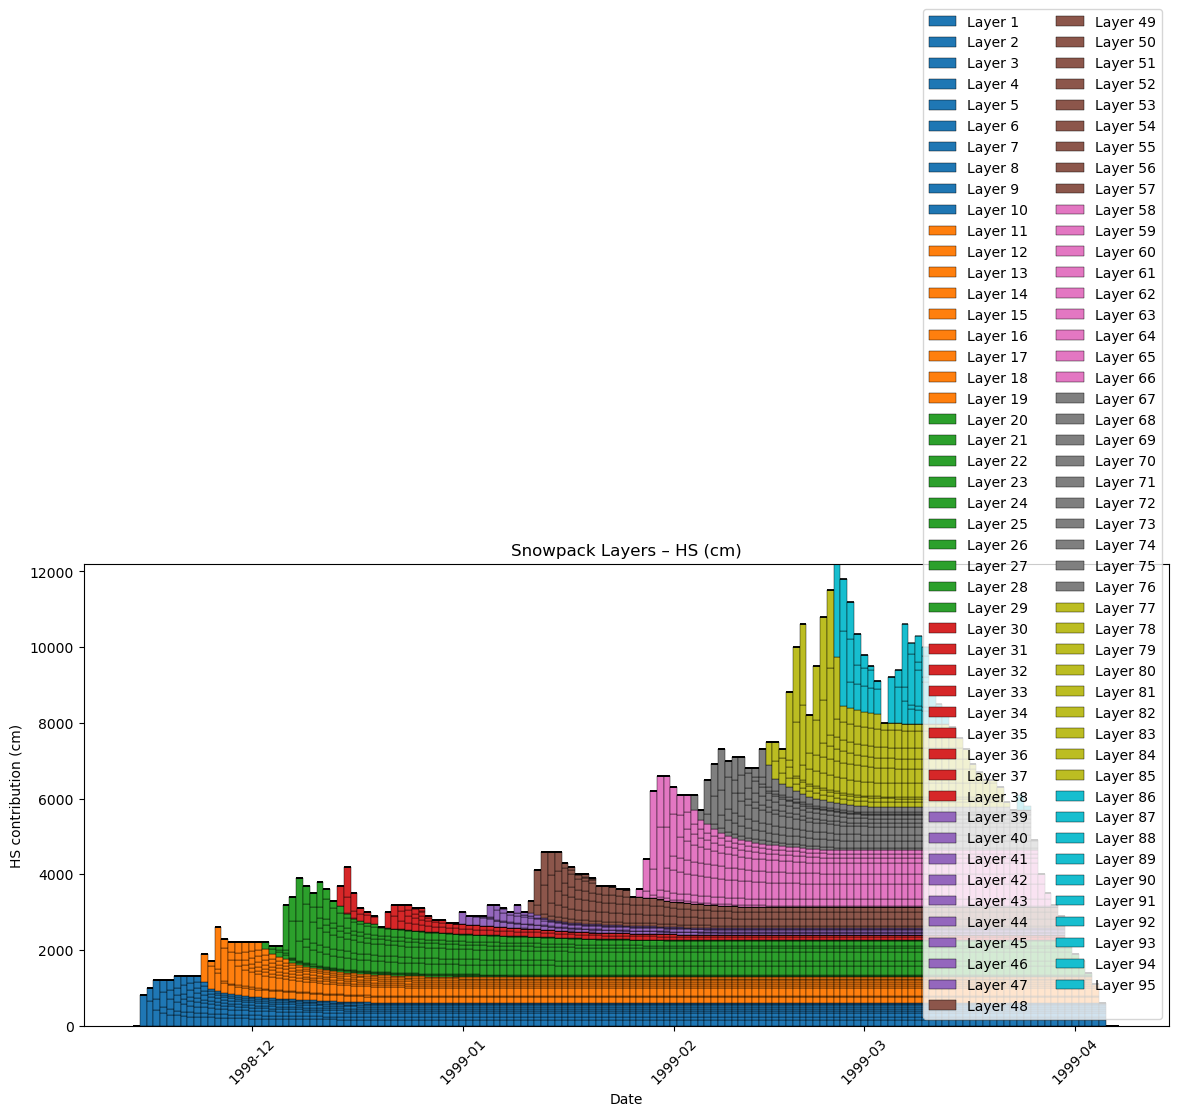

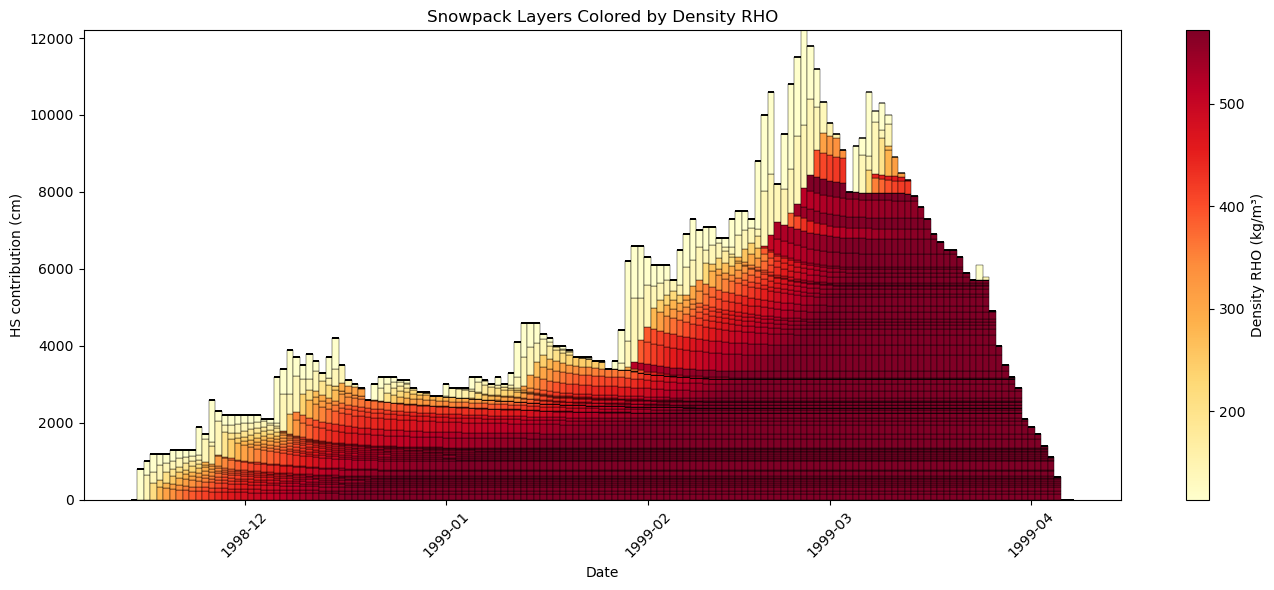

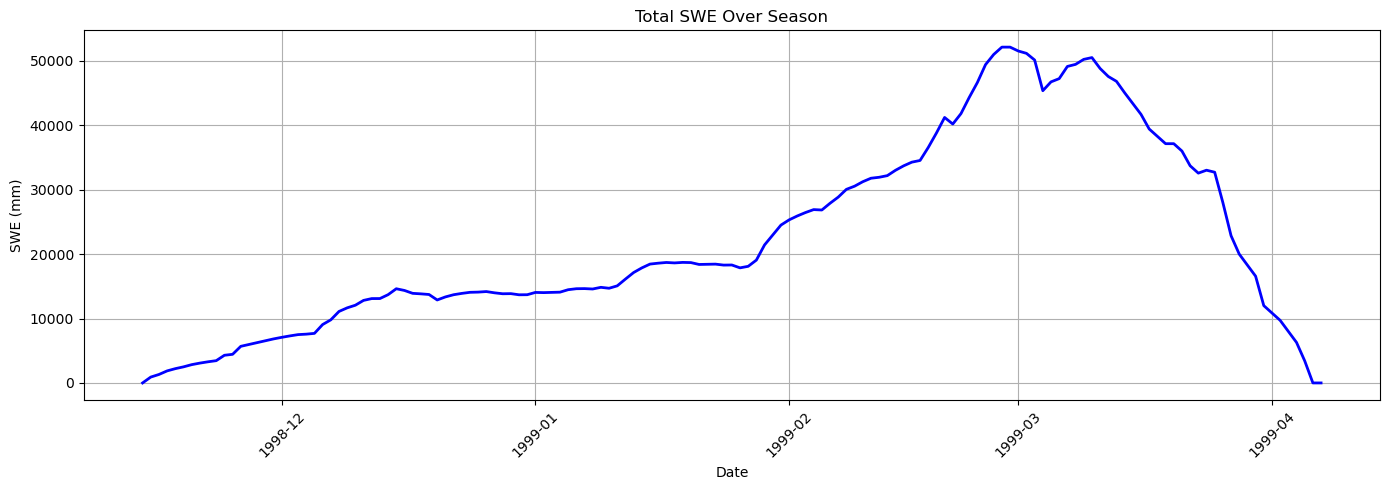

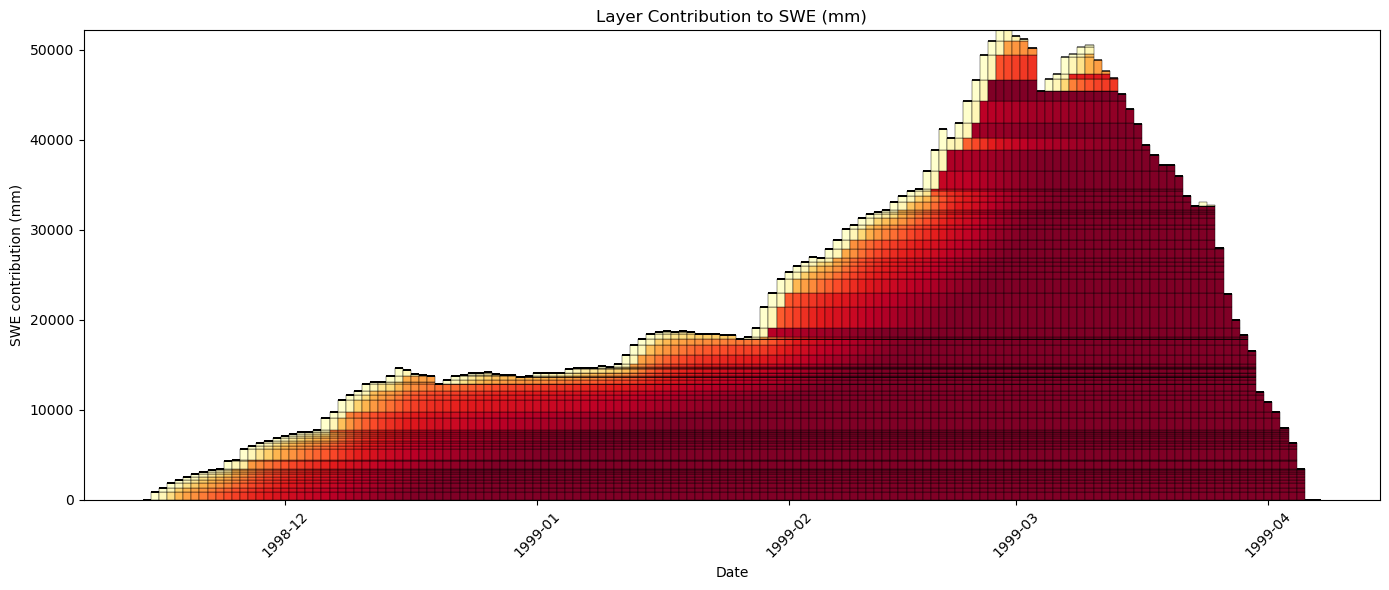

In [ ]:
# ===================================================================
# PLOT: SNOW HEIGHT HS (stacked layers, constant color per layer)
# ===================================================================
fig, ax = plt.subplots(figsize=(14,6))
colors = plt.cm.tab10(np.linspace(0,1,max_layers))

bottom = np.zeros(n_days)
for lyr in range(max_layers):
    ax.bar(
        dates_all,
        HS_full[lyr],
        bottom=bottom,
        color=colors[lyr],
        width=1.0,
        edgecolor='k',
        linewidth=0.3,
        label=f"Layer {lyr+1}"
    )
    bottom += HS_full[lyr]

ax.set_title("Snowpack Layers – HS (cm)")
ax.set_ylabel("HS contribution (cm)")
ax.set_xlabel("Date")
ax.legend(ncol=2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ===================================================================
# PLOT: RHO (Density) stacked by layers with continuous colormap
# ===================================================================
fig, ax = plt.subplots(figsize=(14,6))

mask = np.where(RHO_full > 0, RHO_full, np.nan)
vmin = np.nanmin(mask)
vmax = np.nanmax(mask)
norm = plt.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.YlOrRd

colors = cmap(norm(np.nan_to_num(mask, nan=vmin)))
bottom = np.zeros(n_days)

for lyr in range(max_layers):
    layer_colors = colors[lyr]
    ax.bar(
        dates_all,
        HS_full[lyr],
        bottom=bottom,
        color=layer_colors,
        width=1.0,
        edgecolor='k',
        linewidth=0.3
    )
    bottom += HS_full[lyr]

sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array(mask[np.isfinite(mask)])
plt.colorbar(sm, ax=ax, label="Density RHO (kg/m³)")

ax.set_title("Snowpack Layers Colored by Density RHO")
ax.set_ylabel("HS contribution (cm)")
ax.set_xlabel("Date")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ===================================================================
# RECONSTRUCT SWE_full (if not already done)
# SWE = sum over layers (HS * RHO / 100)
# ===================================================================
SWE_full = np.nansum(HS_full * RHO_full / 100.0, axis=0)   # mm


# ===================================================================
# PLOT SWE AS TIME SERIES
# ===================================================================
plt.figure(figsize=(14,5))
plt.plot(dates_all, SWE_full, linewidth=2, color='blue')
plt.title("Total SWE Over Season")
plt.xlabel("Date")
plt.ylabel("SWE (mm)")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ===================================================================
# OPTIONAL: SWE Layer Contribution Plot
# ===================================================================
fig, ax = plt.subplots(figsize=(14,6))
bottom = np.zeros(n_days)

for lyr in range(max_layers):
    swe_layer = HS_full[lyr] * RHO_full[lyr] / 100.0  # mm
    ax.bar(
        dates_all,
        swe_layer,
        bottom=bottom,
        color=colors[lyr],
        width=1.0,
        edgecolor="k",
        linewidth=0.3
    )
    bottom += swe_layer

ax.set_title("Layer Contribution to SWE (mm)")
ax.set_xlabel("Date")
ax.set_ylabel("SWE contribution (mm)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Delta SNOW Layers

In [ ]:
# the data was run in the ``layer_model_run`` folder and saved as NetCDF
ds_delta_snow = xr.open_dataset("/Users/jakobwerkgarner/code/mt_dsnow/model_diff/dsnow/layer_model_run/delta_snow_result.nc")

#### Density

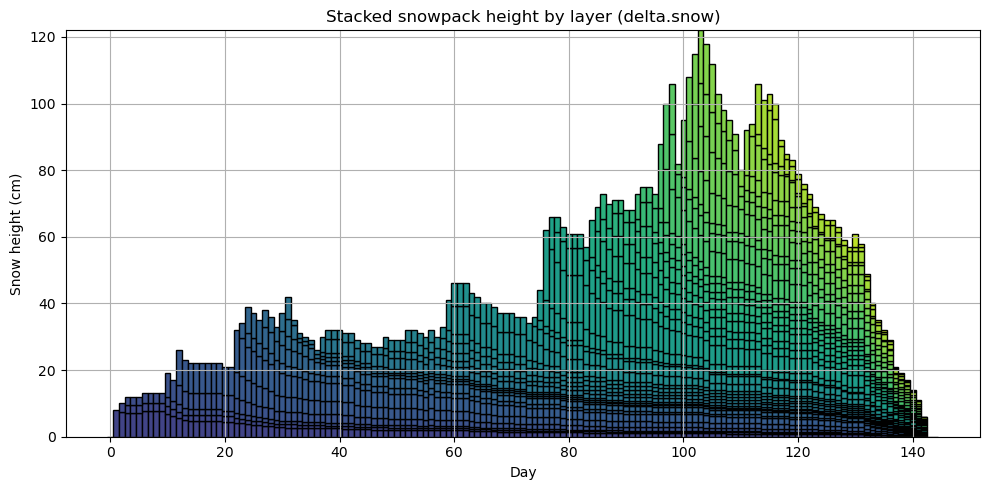

In [ ]:
# ============================================================
# 4b) Stacked bar plot: layer heights as actual snow height
# ============================================================

# Convert h_dsnow from meters to centimeters for plotting
h_dsnow_cm = h_dsnow * 100.0  # shape: (ntime, nlayers)

fig, ax = plt.subplots(figsize=(10, 5))

bottom = np.zeros(ntime)
colors = plt.cm.viridis(np.linspace(0.2, 0.9, nlayers))

for lyr in range(nlayers):
    ax.bar(
        np.arange(ntime),
        h_dsnow_cm[:, lyr],
        bottom=bottom,
        color=colors[lyr],
        width=1.0,
        edgecolor='k'
    )
    bottom += np.nan_to_num(h_dsnow_cm[:, lyr])

ax.set_xlabel("Day")
ax.set_ylabel("Snow height (cm)")
ax.set_title("Stacked snowpack height by layer (delta.snow)")
ax.grid(True)
plt.tight_layout()
plt.show()

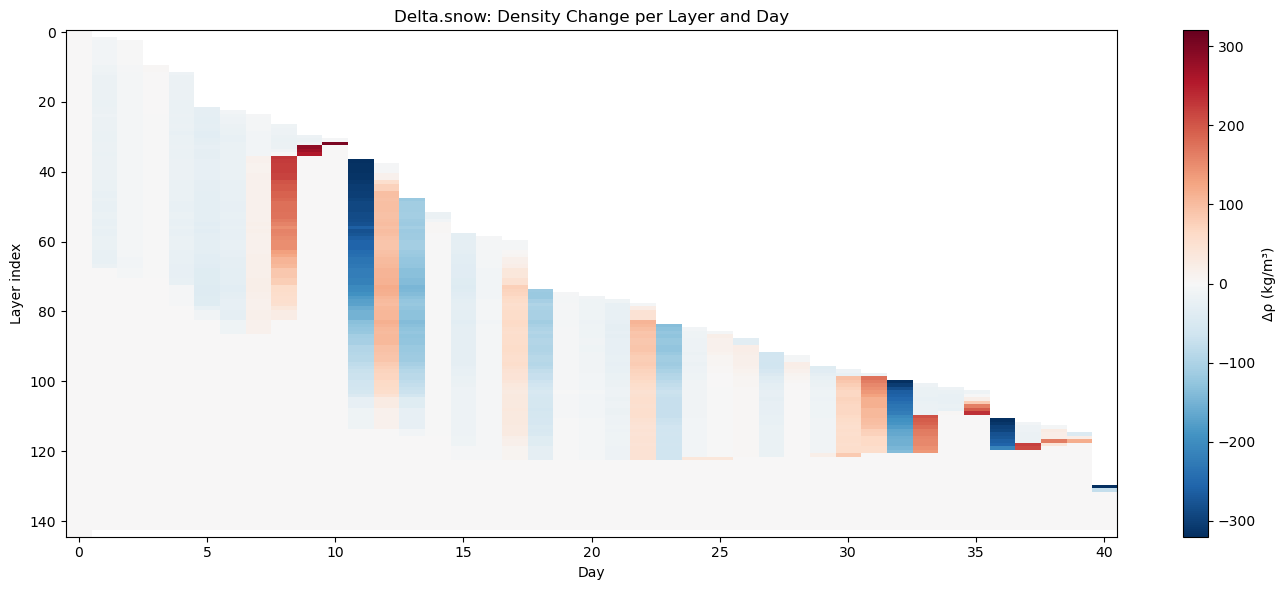

In [ ]:
# Calculate density change (Δρ) for each layer and each day
# Use the already loaded rho_dsnow array (shape: ntime, nlayers)
# Δρ = rho_dsnow[t, lyr] - rho_dsnow[t-1, lyr] for t >= 1

delta_rho_plot = np.zeros_like(rho_dsnow)
delta_rho_plot[1:, :] = rho_dsnow[1:, :] - rho_dsnow[:-1, :]

# Transpose for plotting: layers as rows, days as columns
fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(
    delta_rho_plot.T, 
    aspect='auto', 
    cmap='RdBu_r', 
    interpolation='none',
    vmin=-np.nanmax(np.abs(delta_rho_plot)), 
    vmax=np.nanmax(np.abs(delta_rho_plot))
)
cbar = plt.colorbar(im, ax=ax, label="Δρ (kg/m³)")
ax.set_title("Delta.snow: Density Change per Layer and Day")
ax.set_xlabel("Day")
ax.set_ylabel("Layer index")
plt.tight_layout()
plt.show()

In [ ]:
n_layers_dsnow, n_days_dsnow = h_dsnow.shape

# Initialize diagnostic arrays
delta_rho_dsnow = np.zeros_like(rho_dsnow)
settle_factor_dsnow = np.zeros_like(rho_dsnow)
delta_hs_dsnow = np.zeros_like(h_dsnow_cm)

# Calculate changes over time (t=1 onwards)
for t in range(1, n_days_dsnow):
    for lyr in range(n_layers_dsnow):
        if h_dsnow[lyr, t] > 0 and h_dsnow[lyr, t-1] > 0:
            # Density change
            delta_rho_dsnow[lyr, t] = rho_dsnow[lyr, t] - rho_dsnow[lyr, t-1]
            
            # Settling factor (rho_old / rho_new)
            if rho_dsnow[lyr, t] > 0:
                settle_factor_dsnow[lyr, t] = rho_dsnow[lyr, t-1] / rho_dsnow[lyr, t]
            
            # Height change from settling
            delta_hs_dsnow[lyr, t] = h_dsnow_cm[lyr, t] - h_dsnow_cm[lyr, t-1]

# Densification rate (approximation: delta_rho / dt)
# Assume dt = 1 day = 86400 seconds
dt = 86400
dens_rate_dsnow = delta_rho_dsnow / dt  # kg/(m³·s)

print("Delta.snow diagnostics calculated!")
print(f"  Δρ range: {delta_rho_dsnow[delta_rho_dsnow != 0].min():.2f} - {delta_rho_dsnow[delta_rho_dsnow != 0].max():.2f} kg/m³")
print(f"  Settling factor range: {settle_factor_dsnow[settle_factor_dsnow > 0].min():.4f} - {settle_factor_dsnow[settle_factor_dsnow > 0].max():.4f}")

IndexError: index 41 is out of bounds for axis 0 with size 41

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (145,) and arg 1 with shape (41,).

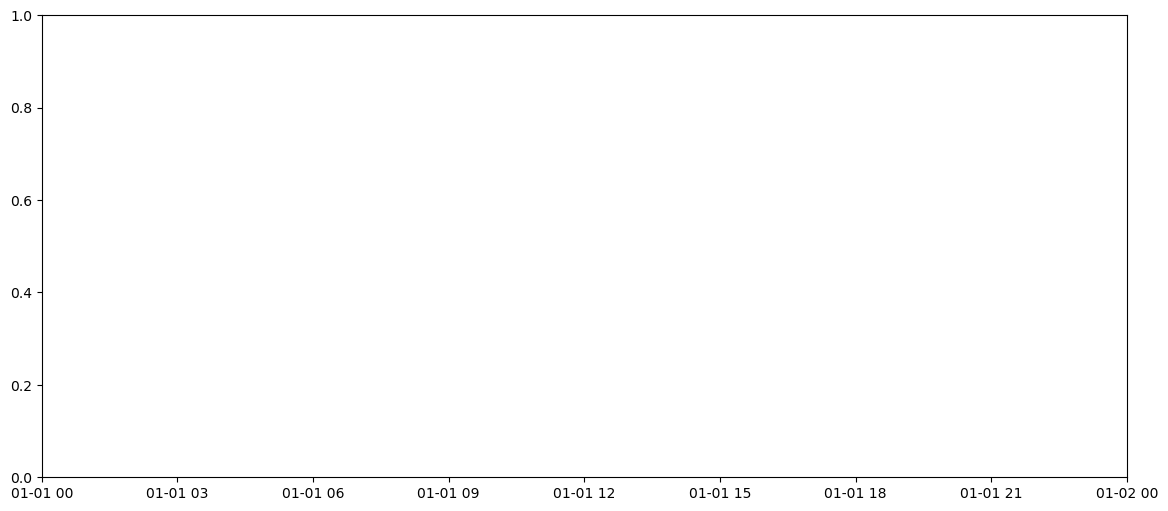

In [ ]:
# ===================================================================
# PLOT DELTA.SNOW: SNOW HEIGHT HS (stacked layers)
# ===================================================================
fig, ax = plt.subplots(figsize=(14,6))
colors_dsnow = plt.cm.tab10(np.linspace(0, 1, n_layers_dsnow))

bottom = np.zeros(n_days_dsnow)
for lyr in range(n_layers_dsnow):
    ax.bar(
        dates_all,
        h_dsnow_cm[lyr],
        bottom=bottom,
        color=colors_dsnow[lyr],
        width=1.0,
        edgecolor='k',
        linewidth=0.3,
        label=f"Layer {lyr+1}"
    )
    bottom += h_dsnow_cm[lyr]

ax.set_title("Delta.snow Snowpack Layers – HS (cm)")
ax.set_ylabel("HS contribution (cm)")
ax.set_xlabel("Date")
ax.legend(ncol=2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# ===================================================================
# PLOT DELTA.SNOW: DENSITY RHO (continuous colormap)
# ===================================================================
fig, ax = plt.subplots(figsize=(14,6))

mask_rho = np.where(rho_dsnow > 0, rho_dsnow, np.nan)
vmin_rho = np.nanmin(mask_rho)
vmax_rho = np.nanmax(mask_rho)
norm_rho = plt.Normalize(vmin=vmin_rho, vmax=vmax_rho)
cmap_rho = plt.cm.YlOrRd

colors_rho = cmap_rho(norm_rho(np.nan_to_num(mask_rho, nan=vmin_rho)))
bottom = np.zeros(n_days_dsnow)

for lyr in range(n_layers_dsnow):
    layer_colors = colors_rho[lyr]
    ax.bar(
        dates_all,
        h_dsnow_cm[lyr],
        bottom=bottom,
        color=layer_colors,
        width=1.0,
        edgecolor='k',
        linewidth=0.3
    )
    bottom += h_dsnow_cm[lyr]

sm = plt.cm.ScalarMappable(norm=norm_rho, cmap=cmap_rho)
sm.set_array(mask_rho[np.isfinite(mask_rho)])
plt.colorbar(sm, ax=ax, label="Density RHO (kg/m³)")

ax.set_title("Delta.snow Snowpack Layers Colored by Density RHO")
ax.set_ylabel("HS contribution (cm)")
ax.set_xlabel("Date")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# ===================================================================
# PLOT DELTA.SNOW: DIAGNOSTIC PLOTS (same style as HS2SWE)
# ===================================================================

def plot_dsnow_diagnostic(HS_field, var_field, dates, title, label, cmap):
    """Plot diagnostic field with continuous colormap"""
    mask = np.where(var_field != 0, var_field, np.nan)
    vmin = np.nanmin(mask)
    vmax = np.nanmax(mask)
    
    if np.isnan(vmin) or np.isnan(vmax):
        print(f"Warning: No valid data for {title}")
        return
    
    norm = plt.Normalize(vmin=vmin, vmax=vmax)

    fig, ax = plt.subplots(figsize=(14, 6))
    colors = cmap(norm(np.nan_to_num(mask, nan=vmin)))

    bottom = np.zeros(len(dates))
    L = HS_field.shape[0]

    for lyr in range(L):
        layer_colors = [colors[lyr, t] for t in range(len(dates))]
        ax.bar(
            dates,
            HS_field[lyr],
            bottom=bottom,
            color=layer_colors,
            width=1.0,
            edgecolor="k",
            linewidth=0.3
        )
        bottom += HS_field[lyr]

    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array(mask[np.isfinite(mask)])
    plt.colorbar(sm, ax=ax, label=label)

    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel("HS contribution (cm)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# Plot all diagnostics
plot_dsnow_diagnostic(h_dsnow_cm, delta_rho_dsnow, dates_all,
                      "Delta.snow: Density Increment Δρ per timestep", 
                      "Δρ (kg/m³)", plt.cm.RdBu_r)

plot_dsnow_diagnostic(h_dsnow_cm, dens_rate_dsnow, dates_all,
                      "Delta.snow: Densification Rate", 
                      "dρ/dt (kg/(m³·s))", plt.cm.viridis)

plot_dsnow_diagnostic(h_dsnow_cm, settle_factor_dsnow, dates_all,
                      "Delta.snow: Settling Factor (ρ_old / ρ_new)", 
                      "SETTLE_FACTOR", plt.cm.Blues)

plot_dsnow_diagnostic(h_dsnow_cm, delta_hs_dsnow, dates_all,
                      "Delta.snow: Snow Height Change ΔHS", 
                      "ΔHS (cm)", plt.cm.cividis)

plot_dsnow_diagnostic(h_dsnow_cm, age_dsnow, dates_all,
                      "Delta.snow: Layer Age", 
                      "Age (days)", plt.cm.plasma)

In [ ]:
# ===================================================================
# PLOT DELTA.SNOW: TOTAL SWE TIME SERIES
# ===================================================================
plt.figure(figsize=(14,5))
plt.plot(dates_all, swe_total_dsnow, linewidth=2, color='blue', label='Delta.snow SWE')
plt.title("Delta.snow Total SWE Over Season")
plt.xlabel("Date")
plt.ylabel("SWE (mm)")
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# ===================================================================
# PLOT DELTA.SNOW: SWE LAYER CONTRIBUTION
# ===================================================================
fig, ax = plt.subplots(figsize=(14,6))
bottom = np.zeros(n_days_dsnow)

for lyr in range(n_layers_dsnow):
    ax.bar(
        dates_all,
        swe_layer_dsnow[lyr],
        bottom=bottom,
        color=colors_dsnow[lyr],
        width=1.0,
        edgecolor="k",
        linewidth=0.3,
        label=f"Layer {lyr+1}"
    )
    bottom += swe_layer_dsnow[lyr]

ax.set_title("Delta.snow Layer Contribution to SWE (mm)")
ax.set_xlabel("Date")
ax.set_ylabel("SWE contribution (mm)")
ax.legend(ncol=2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Comparison: HS2SWE vs Delta.snow

In [ ]:
# ===================================================================
# SIDE-BY-SIDE COMPARISON: HS2SWE vs Delta.snow
# ===================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 1: HS2SWE
# Snow Height
ax = axes[0, 0]
bottom = np.zeros(n_days)
for lyr in range(max_layers):
    ax.bar(dates_all, HS_full[lyr], bottom=bottom, color=colors[lyr], width=1.0, edgecolor='k', linewidth=0.2)
    bottom += HS_full[lyr]
ax.set_title("HS2SWE: Snow Height")
ax.set_ylabel("HS (cm)")
ax.tick_params(axis='x', rotation=45, labelsize=8)

# Density
ax = axes[0, 1]
mask = np.where(RHO_full > 0, RHO_full, np.nan)
vmin = np.nanmin(mask)
vmax = np.nanmax(mask)
norm = plt.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.YlOrRd
colors_rho_hs2swe = cmap(norm(np.nan_to_num(mask, nan=vmin)))
bottom = np.zeros(n_days)
for lyr in range(max_layers):
    ax.bar(dates_all, HS_full[lyr], bottom=bottom, color=colors_rho_hs2swe[lyr], width=1.0, edgecolor='k', linewidth=0.2)
    bottom += HS_full[lyr]
ax.set_title("HS2SWE: Density")
ax.set_ylabel("HS (cm)")
ax.tick_params(axis='x', rotation=45, labelsize=8)

# SWE
ax = axes[0, 2]
ax.plot(dates_all, SWE_full, linewidth=2, color='blue')
ax.set_title("HS2SWE: Total SWE")
ax.set_ylabel("SWE (mm)")
ax.grid(True)
ax.tick_params(axis='x', rotation=45, labelsize=8)


# Row 2: Delta.snow
# Snow Height
ax = axes[1, 0]
bottom = np.zeros(n_days_dsnow)
for lyr in range(n_layers_dsnow):
    ax.bar(dates_all, h_dsnow_cm[lyr], bottom=bottom, color=colors_dsnow[lyr], width=1.0, edgecolor='k', linewidth=0.2)
    bottom += h_dsnow_cm[lyr]
ax.set_title("Delta.snow: Snow Height")
ax.set_ylabel("HS (cm)")
ax.set_xlabel("Date")
ax.tick_params(axis='x', rotation=45, labelsize=8)

# Density
ax = axes[1, 1]
mask_ds = np.where(rho_dsnow > 0, rho_dsnow, np.nan)
vmin_ds = np.nanmin(mask_ds)
vmax_ds = np.nanmax(mask_ds)
norm_ds = plt.Normalize(vmin=vmin_ds, vmax=vmax_ds)
colors_rho_ds = cmap(norm_ds(np.nan_to_num(mask_ds, nan=vmin_ds)))
bottom = np.zeros(n_days_dsnow)
for lyr in range(n_layers_dsnow):
    ax.bar(dates_all, h_dsnow_cm[lyr], bottom=bottom, color=colors_rho_ds[lyr], width=1.0, edgecolor='k', linewidth=0.2)
    bottom += h_dsnow_cm[lyr]
ax.set_title("Delta.snow: Density")
ax.set_ylabel("HS (cm)")
ax.set_xlabel("Date")
ax.tick_params(axis='x', rotation=45, labelsize=8)

# SWE
ax = axes[1, 2]
ax.plot(dates_all, swe_total_dsnow, linewidth=2, color='red')
ax.set_title("Delta.snow: Total SWE")
ax.set_ylabel("SWE (mm)")
ax.set_xlabel("Date")
ax.grid(True)
ax.tick_params(axis='x', rotation=45, labelsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# ===================================================================
# QUANTITATIVE COMPARISON: SWE difference between models
# ===================================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Plot both SWE series
axes[0].plot(dates_all, SWE_full, linewidth=2, color='blue', label='HS2SWE', marker='o', markersize=3)
axes[0].plot(dates_all, swe_total_dsnow, linewidth=2, color='red', label='Delta.snow', marker='s', markersize=3)
axes[0].set_ylabel("SWE (mm)")
axes[0].set_title("SWE Comparison: HS2SWE vs Delta.snow")
axes[0].grid(True)
axes[0].legend()

# Plot difference
swe_diff = SWE_full - swe_total_dsnow
axes[1].plot(dates_all, swe_diff, linewidth=2, color='purple', marker='d', markersize=3)
axes[1].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[1].set_ylabel("SWE Difference (mm)")
axes[1].set_xlabel("Date")
axes[1].set_title("SWE Difference (HS2SWE - Delta.snow)")
axes[1].grid(True)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print statistics
print("\n=== SWE Comparison Statistics ===")
print(f"Mean HS2SWE SWE: {np.mean(SWE_full):.2f} mm")
print(f"Mean Delta.snow SWE: {np.mean(swe_total_dsnow):.2f} mm")
print(f"Mean Difference: {np.mean(swe_diff):.2f} mm")
print(f"RMSE: {np.sqrt(np.mean(swe_diff**2)):.2f} mm")
print(f"Max Difference: {np.max(np.abs(swe_diff)):.2f} mm")
print(f"Correlation: {np.corrcoef(SWE_full, swe_total_dsnow)[0,1]:.4f}")